In [2]:
from guppylang.std.builtins import array, control, nat, qubit
from guppylang import guppy
from guppylang.std.quantum import measure_array, x, h, measure, cx, cz

from hugr.hugr.render import RenderConfig
from guppylang import enable_experimental_features
enable_experimental_features()

n = guppy.nat_var("n")
c = guppy.nat_var("c")

@guppy
def helper(q1: qubit) -> None:
    h(q1)


@guppy.unitary
class foo:

    @guppy #(daggerable=True)
    def __call__(q1: array[qubit, n]) -> None:
        h(q1[0])
        # helper(q1[0])

    # @guppy
    # def daggered(q1: array[qubit, n]) -> None:
    #     x(q1[0])

    # @guppy
    # def controlled(q1: array[qubit, n], _controls: array[qubit, c]) -> None:
    #     cz(_controls[0], q1[0])
        

    @guppy
    def ctrl_daggered(q1: array[qubit, n], _controls: array[qubit, c]) -> None:
        cx(_controls[0], q1[0])
        foo.controlled(q1, _controls)
        


foo.check()


TypeError: A custom `ctrl_daggered` implementation requires both controllable and daggerable support, or `unitary=True` on `__call__`

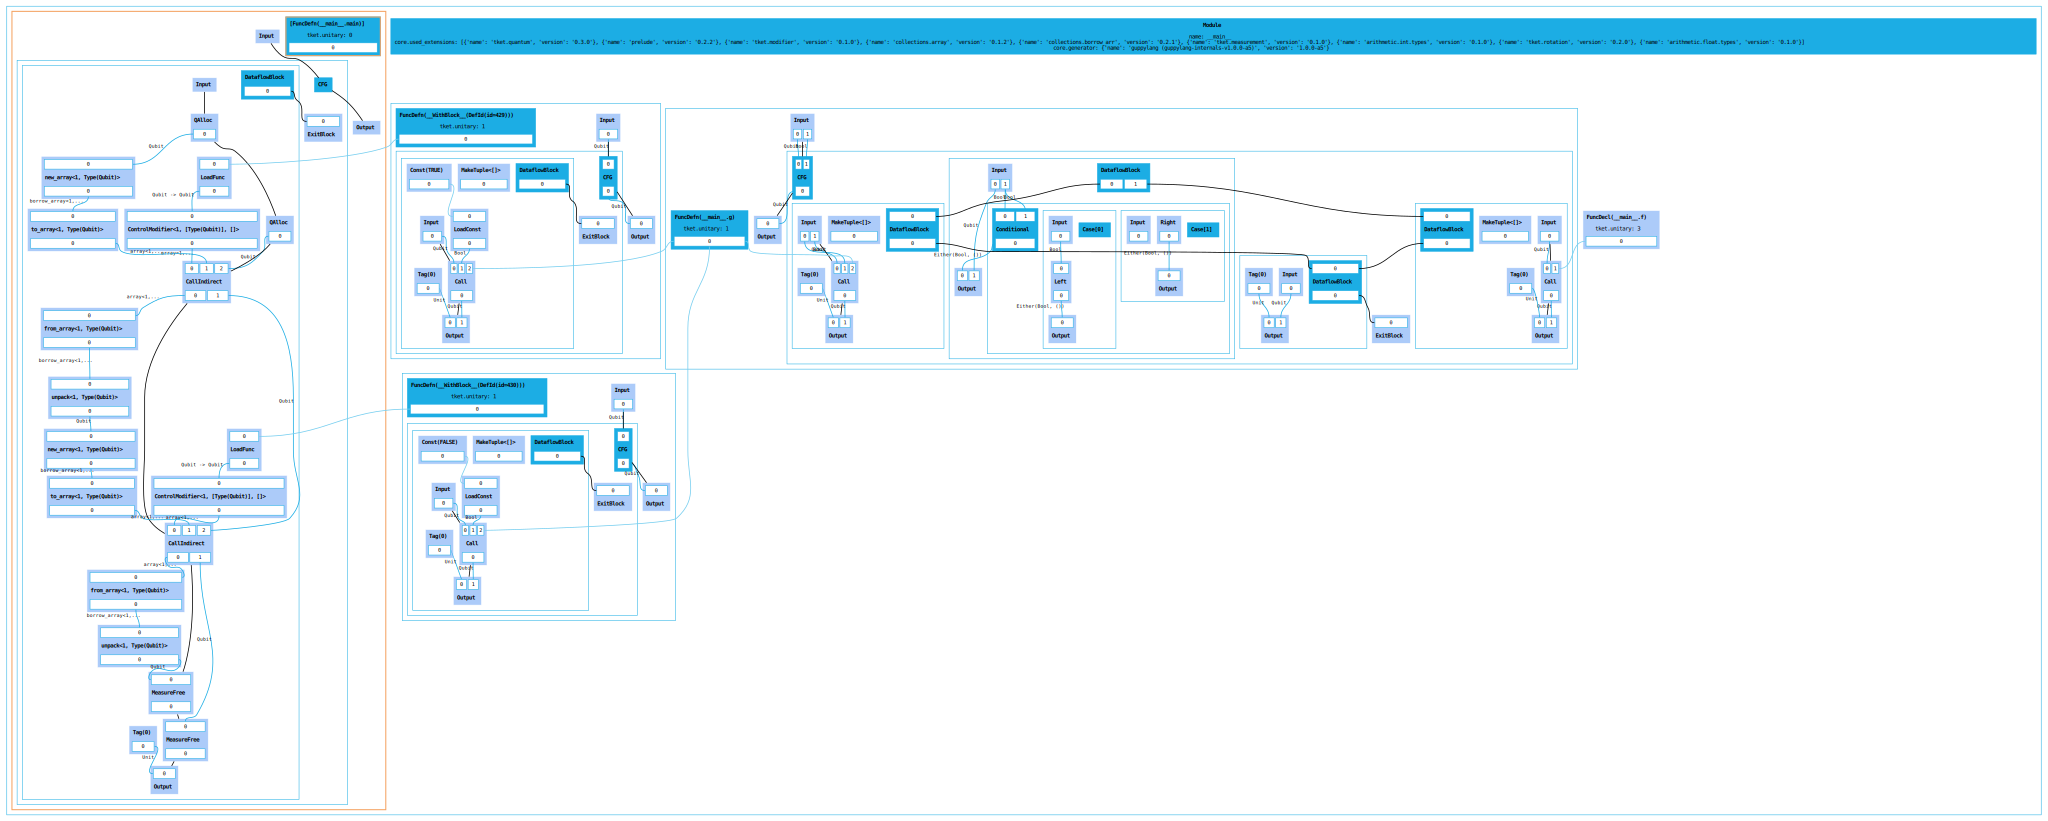

In [6]:
from guppylang.std.builtins import array, control, nat, qubit
from guppylang import guppy
from guppylang.std.quantum import measure_array, x, h, measure, cx, cz

from hugr.hugr.render import RenderConfig
from guppylang import enable_experimental_features
enable_experimental_features()

n = guppy.nat_var("n")
c = guppy.nat_var("c")

@guppy
def helper(q1: qubit) -> None:
    h(q1)


@guppy.unitary
class foo:

    @guppy
    def __call__(q1: array[qubit, n]) -> None:
        h(q1[0])
        helper(q1[0])

    # @guppy
    # def daggered(q1: array[qubit, n]) -> None: ...
    #     x(q1[0])

    @guppy
    def controlled(q1: array[qubit, n], _controls: array[qubit, c]) -> None:
        cz(_controls[0], q1[0])
        

    @guppy
    def call_ctrl_daggered(q1: array[qubit, n], _controls: array[qubit, c]) -> None:
        cx(_controls[0], q1[0])
        foo.controlled(q1, _controls)
        

@guppy.declare(unitary=True)
def f(q1: qubit) -> None: ...

@guppy(controllable=True)
def g(q1: qubit, b: bool) -> None:
    if b:
        f(q1)
    else:
        g(q1, b)

@guppy
def main() -> None:
    q1 = qubit()
    q2 = qubit()
    with control(q1):
        g(q2, True)

    with control(q1):
        g(q2, False)
    # foo(q1)
    measure(q1)
    measure(q2)

main.check()
main.compile().modules[0].render_dot(RenderConfig(max_node_label_length=50, max_metadata_length=None)) #.view()


In [ ]:
@guppy.protocol
class MyProto:
    @guppy.require
    def foo(self: "MyProto", xaaaa: int) -> str: ...

@guppy.struct(frozen=True)
class MyType:
    @guppy
    def foo(self: "MyType", t: int) -> str:
        return "something"

@guppy
def bar[M: MyProto](a: M) -> str:
    return a.foo(42)

# Internally desugared this should be equivalent to `bar`.
@guppy
def baz(a: MyProto) -> str:
    return a.foo(42)

@guppy
def main() -> None:
    mt = MyType()
    bar(mt)
    baz(mt)

main.compile()

In [ ]:
from collections.abc import Callable

from guppylang.decorator import guppy
from guppylang.std.array import array

from guppylang.std.builtins import (
    Controllable,
    Daggerable,
    Unitary,
    control,
    dagger,
    owned,
    power,
    result,
)
from guppylang.std.num import nat
from guppylang.std.quantum import (
    angle,
    cx,
    discard,
    h,
    measure,
    qubit,
    rx,
    discard_array,
)
from guppylang_internals.metadata.common import (
    CONTROLLED_KEY,
    CTRL_DAGGERED_KEY,
    DAGGERED_KEY,
)
from hugr.ops import FuncDefn

def test_unitary_class_functions_are_regular_functions():
    @guppy.unitary
    class foo:
        @guppy
        def helper(q: qubit) -> None:
            h(q)

        @guppy
        def __call__(q: qubit) -> None:
            helper(q)

        @guppy
        def call_daggered(q: qubit) -> None:
            helper(q)

        @guppy
        def call_controlled(q: qubit, _controls: array[qubit, 1]) -> None:
            helper(q)
            helper(_controls[0])

        @guppy
        def call_ctrl_daggered(q: qubit, _controls: array[qubit, 1]) -> None:
            helper(q)
            helper(_controls[0])

    @guppy
    def main() -> None:
        q = qubit()
        foo(q)
        result("r", measure(q).read())

    return main

test_unitary_class_functions_are_regular_functions().emulator(n_qubits=1).with_shots(100).run().collated_counts()

In [1]:

from guppylang.decorator import guppy
from guppylang.std.array import array

from guppylang.std.builtins import (
    control,
    dagger,
)
from guppylang.std.num import nat
from guppylang.std.quantum import ( cx,
    h, x,
    measure,
    qubit)
import guppylang
guppylang.enable_experimental_features()

def test_unitary_class_functions_are_regular_functions():
    @guppy.unitary
    class foo:
        @guppy
        def __call__(q: qubit) -> None:
            h(q)
            c = qubit()
            measure(c)

        @guppy
        def call_daggered(q: qubit) -> None:
            x(q)

        # @guppy
        # def call_controlled[c: nat](q: qubit, _controls: array[qubit, c]) -> None:
        #     cx(q, _controls[0])

        # @guppy
        # def call_ctrl_daggered(q: qubit, _controls: array[qubit, 1]) -> None:
        #     cx(q, _controls[0])

    @guppy
    def main() -> None:
        q = qubit()
        c = qubit()
        with control(c):
            foo(q)
        with dagger:
            foo(q)
        with control(c), dagger:
            foo(q)
        measure(q)
        measure(c)

    return main

test_unitary_class_functions_are_regular_functions().check()

Error: Control constraint violation (at <In[1]>:42:12)
   | 
40 |         c = qubit()
41 |         with control(c):
42 |             foo(q)
   |             ^^^^^^ This function cannot be called in a controllable context

Help: The `@guppy.unitary` function `foo` is missing a custom implementation.
Consider implementing the custom method `call_controlled`

Guppy compilation failed due to 1 previous error


In [5]:

from guppylang.decorator import guppy
from guppylang.std.array import array

from guppylang.std.builtins import (
    control,
    dagger,
)
from guppylang.std.num import nat
from guppylang.std.quantum import ( cx,
    h, x,
    measure,
    qubit)
import guppylang
guppylang.enable_experimental_features()

def test_unitary_class_functions_are_regular_functions():
    @guppy.unitary
    class foo:
        @guppy
        def __call__(q: qubit) -> None:
            h(q)
            c = qubit()
            measure(c)

        @guppy
        def call_daggered(q: qubit) -> None:
            x(q)

        @guppy
        def call_controlled[c: nat](q: qubit, _controls: array[qubit, c]) -> None:
            cx(q, _controls[0])

        # @guppy
        # def call_ctrl_daggered(q: qubit, _controls: array[qubit, 1]) -> None:
        #     cx(q, _controls[0])

    @guppy(daggerable=True)
    def main(q: qubit) -> None:
        foo(q)
        
    return main

test_unitary_class_functions_are_regular_functions().compile_function().modules[0].render_dot()

Traceback (most recent call last):
  File "/Users/nicola.assolini/Documents/GitHub/guppylang/.venv/lib/python3.13/site-packages/IPython/core/interactiveshell.py", line 3748, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
    ~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/var/folders/sx/bbzfd6mn5txdvh5bghnjgp5m0000gp/T/ipykernel_11985/1679268340.py", line 43, in <module>
    test_unitary_class_functions_are_regular_functions().compile_function().modules[0].render_dot()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/Users/nicola.assolini/Documents/GitHub/guppylang/guppylang/src/guppylang/defs.py", line 256, in compile_function
    return super().compile()
           ~~~~~~~~~~~~~~~^^
  File "/Users/nicola.assolini/Documents/GitHub/guppylang/guppylang/src/guppylang/defs.py", line 89, in compile
    package: Package = ENGINE.compile_single(self.id).package
                       ~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^
  File "/Use

In [ ]:
from guppylang import guppy, qubit
from guppylang.std.builtins import owned


@guppy.declare(unitary=True)
def uni_discard(q: qubit @owned) -> None: ...


@guppy(unitary=True)
def test() -> None:
    p = qubit()
    uni_discard(p)

test.compile()
